## Model Comparison on Plan Correctness Estimation

This notebook trains and evaluates **Random Forest**, **XGBoost**, and **MLP**
models to predict plan correctness
scores ∈ [0, 1].

**Feature sources**:
- `ad_lstm_wl_delta`, `ad_xgb_wl_delta`
- `dd_lstm_shortest_path_delta`, `dd_xgb_wl_delta`

**Metrics**:
- **MAE**: lower is better;
- **RMSE**: lower is better;
- **R²**: higher is better.

#### Setup

In [2]:
import gc
import json
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)

# 13, 23, 37 - project seeds
SEED = 23
np.random.seed(SEED)

FAMILIES = [
    "ad_lstm_wl_delta",
    "ad_xgb_wl_delta",
    "dd_lstm_shortest_path_delta",
    "dd_xgb_wl_delta",
]
SPLITS = ["train", "validation", "test-interpolation", "test-extrapolation"]

FEATURE_DIR = Path("../../data/correctness_dataset/features")
RESULTS_DIR = Path(f"../../results/model_comparison/seed_{SEED}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Seed: {SEED}")
print(f"Families: {FAMILIES}")
print(f"Results dir: {RESULTS_DIR.resolve()}")
print(f"DEVICE: {DEVICE}")

Seed: 23
Families: ['ad_lstm_wl_delta', 'ad_xgb_wl_delta', 'dd_lstm_shortest_path_delta', 'dd_xgb_wl_delta']
Results dir: /home/bernardod/desktop/research/planfm-validity/results/model_comparison/seed_23
DEVICE: cuda


#### Data Loading

In [3]:
def load_family_data(family: str, feature_dir: Path) -> dict:
    """Load all splits for a single family."""
    data = {}
    for split in SPLITS:
        path = feature_dir / family / f"seed_{SEED}" / f"{split}.npz"
        npz = dict(np.load(path, allow_pickle=True))
        data[split] = {
            "X": npz["X"].astype(np.float32),
            "y": npz["correctness_scores"].astype(np.float32),
            "feature_names": list(npz["feature_names"]),
            "domains": npz["domains"],
            "corruption_types": npz["corruption_types"],
            "candidate_ids": npz["candidate_ids"],
        }
    return data


# Print sample counts per family/split
summary_rows = []
for family in FAMILIES:
    for split in SPLITS:
        path = FEATURE_DIR / family / f"seed_{SEED}" / f"{split}.npz"
        npz = dict(np.load(path, allow_pickle=True))
        y = npz["correctness_scores"].astype(np.float32)
        summary_rows.append({
            "family": family, "split": split,
            "n": len(y), "mean": f"{y.mean():.3f}", "std": f"{y.std():.3f}",
        })
        del npz
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

                     family              split    n  mean   std
           ad_lstm_wl_delta              train 1156 0.607 0.314
           ad_lstm_wl_delta         validation  165 0.645 0.299
           ad_lstm_wl_delta test-interpolation  260 0.591 0.320
           ad_lstm_wl_delta test-extrapolation 1365 0.659 0.299
            ad_xgb_wl_delta              train 1156 0.607 0.314
            ad_xgb_wl_delta         validation  165 0.645 0.299
            ad_xgb_wl_delta test-interpolation  260 0.591 0.320
            ad_xgb_wl_delta test-extrapolation 1365 0.659 0.299
dd_lstm_shortest_path_delta              train 1156 0.607 0.314
dd_lstm_shortest_path_delta         validation  165 0.645 0.299
dd_lstm_shortest_path_delta test-interpolation  260 0.591 0.320
dd_lstm_shortest_path_delta test-extrapolation 1365 0.659 0.299
            dd_xgb_wl_delta              train 1156 0.607 0.314
            dd_xgb_wl_delta         validation  165 0.645 0.299
            dd_xgb_wl_delta test-interpo

#### Preprocessing

- **RF & XGBoost**: use raw features.
- **MLP**: standardize using train-set.

In [4]:
def fit_scaler(X_train: np.ndarray) -> StandardScaler:
    return StandardScaler().fit(X_train)

#### Hyperparameter Grids

In [5]:
# Random Forest Grid
RF_PARAM_GRID = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}
print(f"RF grid: {len(list(ParameterGrid(RF_PARAM_GRID)))} configurations")

# XGBoost Grid
XGB_PARAM_GRID = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
}
print(f"XGB grid: {len(list(ParameterGrid(XGB_PARAM_GRID)))} configurations")

import itertools

hidden_dims_options = [
    [64, 32],
    [64, 32, 16],
    [128, 64],
    [128, 64, 32]
]
lr_options = [1e-3, 3e-4]
dropout_options = [0.1, 0.2, 0.3]

MLP_CONFIGS = [
    {"hidden_dims": hd, "lr": lr, "dropout": dp, "weight_decay": 1e-4}
    for hd, lr, dp in itertools.product(hidden_dims_options, lr_options, dropout_options)
]

MLP_EPOCHS = 150
MLP_BATCH_SIZE = 64
MLP_PATIENCE = 20

print(f"MLP configs: {len(MLP_CONFIGS)} configurations")

RF grid: 27 configurations
XGB grid: 36 configurations
MLP configs: 24 configurations


#### MLP Model Definition

In [6]:
class RegressionMLP(nn.Module):
    """Small MLP for regression with sigmoid output."""

    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float):
        super().__init__()
        layers: list[nn.Module] = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(dropout)])
            prev = h
        self.trunk = nn.Sequential(*layers)
        self.head = nn.Linear(prev, 1)

    def forward(self, x):
        return torch.sigmoid(self.head(self.trunk(x)).squeeze(-1))


def train_mlp(X_train, y_train, X_val, y_val, config):
    """Train one MLP config with early stopping."""
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RegressionMLP(
        input_dim=X_train.shape[1],
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=MLP_BATCH_SIZE, shuffle=True)
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    val_loader = DataLoader(val_ds, batch_size=MLP_BATCH_SIZE, shuffle=False)

    best_val_loss = float("inf")
    best_state = None
    patience_left = MLP_PATIENCE
    history = []

    for epoch in range(1, MLP_EPOCHS + 1):
        # --- Train ---
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.item()))

        # --- Validation ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())
        
        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = MLP_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    return model, best_val_loss, history


def mlp_predict(model, X):
    """Get predictions from MLP model."""
    model.eval()
    with torch.no_grad():
        loader = DataLoader(torch.tensor(X, dtype=torch.float32), batch_size=MLP_BATCH_SIZE)
        preds = [model(xb.to(DEVICE)).cpu().numpy() for xb in loader]
    return np.concatenate(preds)

#### Grid Search Functions

In [7]:
def grid_search_rf(X_train, y_train, X_val, y_val, param_grid):
    """Grid search RF on validation set. Returns (model, best_params)."""
    best_score, best_model, best_params = np.inf, None, None
    for params in ParameterGrid(param_grid):
        model = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
        model.fit(X_train, y_train)
        score = mean_absolute_error(y_val, model.predict(X_val))
        if score < best_score:
            best_score, best_model, best_params = score, model, params
    print(f"  RF best val MAE: {best_score:.4f} | params: {best_params}")
    return best_model, best_params


def grid_search_xgb(X_train, y_train, X_val, y_val, param_grid):
    """Grid search XGBoost on validation set. Returns (model, best_params)."""
    best_score, best_model, best_params = np.inf, None, None
    for params in ParameterGrid(param_grid):
        model = XGBRegressor(**params, random_state=SEED, n_jobs=-1, verbosity=0, device=str(DEVICE))
        model.fit(X_train, y_train)
        score = mean_absolute_error(y_val, model.predict(X_val))
        if score < best_score:
            best_score, best_model, best_params = score, model, params
    print(f"  XGB best val MAE: {best_score:.4f} | params: {best_params}")
    return best_model, best_params


def search_mlp(X_train, y_train, X_val, y_val, configs):
    """Search MLP configs on validation set. Returns (model, best_config, best_history)."""
    best_score, best_model, best_config = np.inf, None, None
    for config in configs:
        model, _, history = train_mlp(X_train, y_train, X_val, y_val, config)
        score = mean_absolute_error(y_val, mlp_predict(model, X_val))
        if score < best_score:
            best_score, best_model, best_config, best_history = score, model, config, history
    print(f"  MLP best val MAE: {best_score:.4f} | config: {best_config}")
    return best_model, best_config, best_history

#### Experiment Loop & CSV Export

Processes one family at a time, saves results, then frees memory.

In [8]:
def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

def save_family_results(family, metrics_rows, predictions_rows, best_params, mlp_history, results_dir):
    """Save per-family CSVs and best_params JSON."""
    out_dir = results_dir / family
    out_dir.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(metrics_rows).to_csv(out_dir / "metrics.csv", index=False)
    pd.DataFrame(predictions_rows).to_csv(out_dir / "predictions.csv", index=False)
    pd.DataFrame(mlp_history).to_csv(out_dir / "mlp_history.csv", index=False)

    with open(out_dir / "best_params.json", "w") as f:
        json.dump(best_params, f, indent=2, default=str)
    print(f"  Saved results to {out_dir}")


all_metrics = []
all_best_params = {}

for family in FAMILIES:
    print(f"\n{'='*60}")
    print(f"Processing: {family}")
    print(f"{'='*60}")

    # --- Load this family's data ---
    family_data = load_family_data(family, FEATURE_DIR)

    X_train = family_data["train"]["X"]
    y_train = family_data["train"]["y"]
    X_val = family_data["validation"]["X"]
    y_val = family_data["validation"]["y"]
    feature_names = family_data["train"]["feature_names"]

    # --- Fit scaler (for MLP) ---
    scaler = fit_scaler(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # --- Train models ---
    print("  Training Random Forest...")
    best_rf, rf_params = grid_search_rf(X_train, y_train, X_val, y_val, RF_PARAM_GRID)

    print("  Training XGBoost...")
    best_xgb, xgb_params = grid_search_xgb(X_train, y_train, X_val, y_val, XGB_PARAM_GRID)

    print("  Training MLP...")
    best_mlp, mlp_config, best_mlp_history = search_mlp(X_train_scaled, y_train, X_val_scaled, y_val, MLP_CONFIGS)

    # --- Evaluate on all splits ---
    family_metrics = []
    family_predictions = []
    family_best_params = {"RF": rf_params, "XGB": xgb_params, "MLP": mlp_config}

    models = [
        # (name, model, needs_scaling)
        ("RF", best_rf, False),
        ("XGB", best_xgb, False),
        ("MLP", best_mlp, True),
    ]

    for model_name, model, needs_scaling in models:
        for split in SPLITS:
            X_split = family_data[split]["X"]
            y_split = family_data[split]["y"]

            if needs_scaling:
                X_input = scaler.transform(X_split)
                preds = mlp_predict(model, X_input)
            else:
                preds = model.predict(X_split)

            metrics = compute_metrics(y_split, preds)
            metrics.update({"family": family, "model": model_name, "split": split})
            family_metrics.append(metrics)
            all_metrics.append(metrics)

            # --- Save individual predictions --- 
            for i in range(len(preds)):
                family_predictions.append({
                    "split": split, "model": model_name,
                    "candidate_id": str(family_data[split]["candidate_ids"][i]),
                    "domain": str(family_data[split]["domains"][i]),
                    "true": float(y_split[i]),
                    "pred": float(preds[i]),
                })

    family_best_params["RF_feature_importances"] = dict(zip(feature_names, best_rf.feature_importances_.tolist()))
    family_best_params["XGB_feature_importances"] = dict(zip(feature_names, best_xgb.feature_importances_.tolist()))

    save_family_results(family, family_metrics, family_predictions, family_best_params, best_mlp_history, RESULTS_DIR)
    all_best_params[family] = family_best_params

    # Free memory
    del family_data, best_rf, best_xgb, best_mlp, scaler
    gc.collect()

print(f"\n{'='*60}")
print("All families processed!")


Processing: ad_lstm_wl_delta
  Training Random Forest...
  RF best val MAE: 0.0580 | params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 500}
  Training XGBoost...
  XGB best val MAE: 0.0672 | params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
  Training MLP...
  MLP best val MAE: 0.0474 | config: {'hidden_dims': [128, 64], 'lr': 0.0003, 'dropout': 0.2, 'weight_decay': 0.0001}
  Saved results to ../../results/model_comparison/seed_23/ad_lstm_wl_delta

Processing: ad_xgb_wl_delta
  Training Random Forest...
  RF best val MAE: 0.0525 | params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
  Training XGBoost...
  XGB best val MAE: 0.0615 | params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}
  Training MLP...
  MLP best val MAE: 0.0508 | config: {'hidden_dims': [128, 64], 'lr': 0.001, 'dropout': 0.1, 'weight_decay': 0.0001}
  Saved results to ../../results/model_comparison/seed_23/ad_xgb

#### Results Tables

In [9]:
results_df = pd.DataFrame(all_metrics)

# Save combined summary
results_df.to_csv(RESULTS_DIR / "summary.csv", index=False)
print(f"Saved combined summary to {RESULTS_DIR / 'summary.csv'}")

Saved combined summary to ../../results/model_comparison/seed_23/summary.csv


#### Table 1: Main Results (Validation, Test-Interpolation, Test-Extrapolation)

In [10]:
pivot_splits = ["validation", "test-interpolation", "test-extrapolation"]
table1 = results_df[results_df["split"].isin(pivot_splits)].pivot_table(
    index=["family", "model"],
    columns="split",
    values=["MAE", "RMSE", "R2"],
    aggfunc="first",
)
# Flatten multi-level columns
table1.columns = [f"{metric}_{split}" for metric, split in table1.columns]
table1 = table1.reset_index()

# Reorder columns for readability
col_order = ["family", "model"]
for split in pivot_splits:
    col_order.extend([f"MAE_{split}", f"RMSE_{split}", f"R2_{split}"])
table1 = table1[col_order]

print("\n=== Table 1: Main Results ===")
print(table1.to_string(index=False, float_format="{:.4f}".format))


=== Table 1: Main Results ===
                     family model  MAE_validation  RMSE_validation  R2_validation  MAE_test-interpolation  RMSE_test-interpolation  R2_test-interpolation  MAE_test-extrapolation  RMSE_test-extrapolation  R2_test-extrapolation
           ad_lstm_wl_delta   MLP          0.0474           0.0896         0.9100                  0.0890                   0.1509                 0.7774                  0.1855                   0.2369                 0.3703
           ad_lstm_wl_delta    RF          0.0580           0.1020         0.8834                  0.1017                   0.1597                 0.7509                  0.2568                   0.3332                -0.2460
           ad_lstm_wl_delta   XGB          0.0672           0.1071         0.8714                  0.1023                   0.1592                 0.7523                  0.2883                   0.3712                -0.5463
            ad_xgb_wl_delta   MLP          0.0508           0.098

#### Table 2: Best Hyperparameters

In [11]:
param_rows = []
for family, params in all_best_params.items():
    for model_name in ["RF", "XGB", "MLP"]:
        p = params.get(model_name, {})
        param_rows.append({"family": family, "model": model_name, "best_params": str(p)})
table2 = pd.DataFrame(param_rows)
print("\n=== Table 2: Best Hyperparameters ===")
print(table2.to_string(index=False))


=== Table 2: Best Hyperparameters ===
                     family model                                                                      best_params
           ad_lstm_wl_delta    RF                 {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 500}
           ad_lstm_wl_delta   XGB   {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
           ad_lstm_wl_delta   MLP {'hidden_dims': [128, 64], 'lr': 0.0003, 'dropout': 0.2, 'weight_decay': 0.0001}
            ad_xgb_wl_delta    RF                    {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
            ad_xgb_wl_delta   XGB   {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}
            ad_xgb_wl_delta   MLP  {'hidden_dims': [128, 64], 'lr': 0.001, 'dropout': 0.1, 'weight_decay': 0.0001}
dd_lstm_shortest_path_delta    RF                    {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
dd_lstm_shortest_path_delta   XGB   {'lea

#### 8. Visualizations

#####  8.1 Heatmap: R² on Test-Interpolation

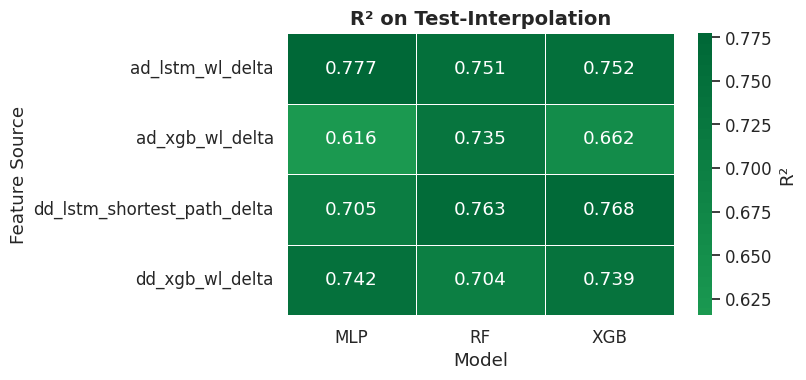

In [12]:
extrap = results_df[results_df["split"] == "test-interpolation"].pivot(
    index="family", columns="model", values="R2"
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(extrap, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"label": "R²"})
ax.set_title("R² on Test-Interpolation", fontsize=14, fontweight="bold")
ax.set_ylabel("Feature Source")
ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_r2_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

#####  8.2 Heatmap: R² on Test-Extrapolation

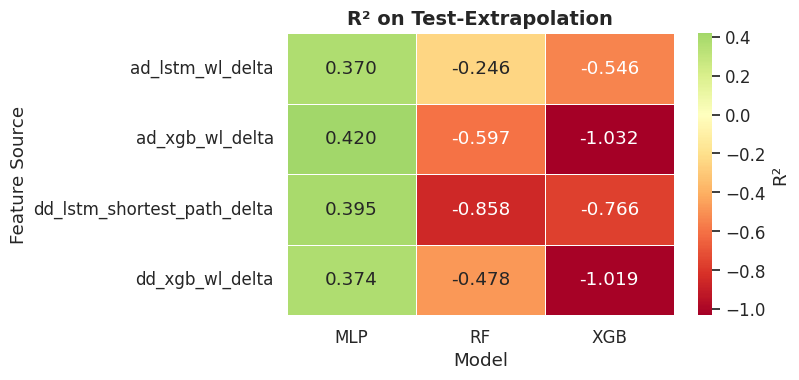

In [13]:
extrap = results_df[results_df["split"] == "test-extrapolation"].pivot(
    index="family", columns="model", values="R2"
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(extrap, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"label": "R²"})
ax.set_title("R² on Test-Extrapolation", fontsize=14, fontweight="bold")
ax.set_ylabel("Feature Source")
ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_r2_extrapolation.png", dpi=150, bbox_inches="tight")
plt.show()

##### 8.2 Grouped Bar Chart: MAE by Model and Family

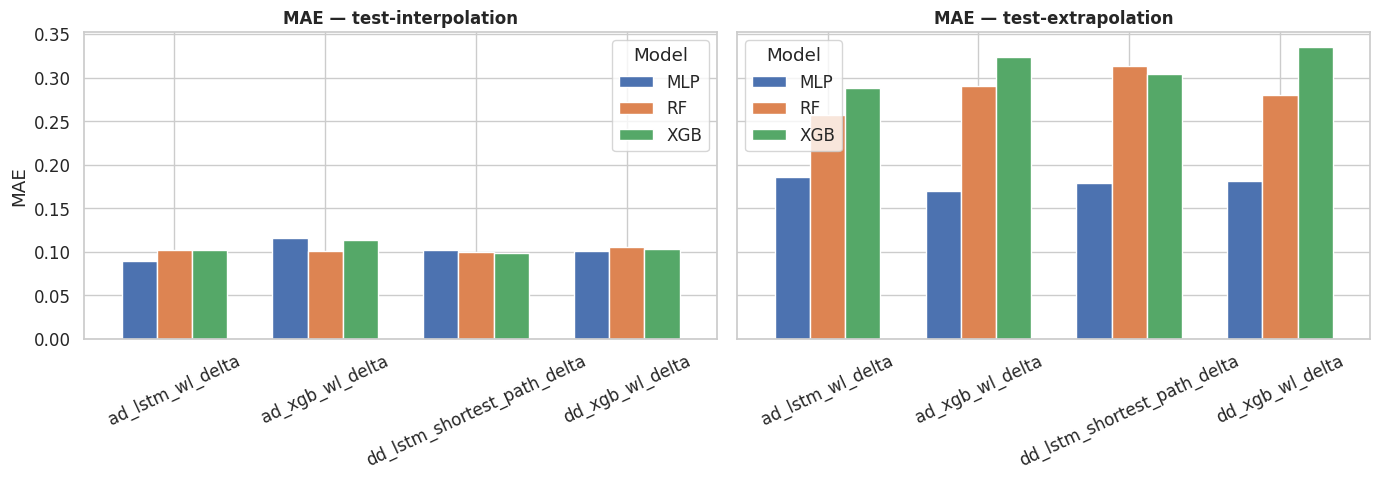

In [14]:
eval_df = results_df[results_df["split"].isin(["test-interpolation", "test-extrapolation"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, split in zip(axes, ["test-interpolation", "test-extrapolation"]):
    split_data = eval_df[eval_df["split"] == split]
    pivot = split_data.pivot(index="family", columns="model", values="MAE")
    pivot.plot(kind="bar", ax=ax, rot=25, width=0.7)
    ax.set_title(f"MAE — {split}", fontsize=12, fontweight="bold")
    ax.set_ylabel("MAE")
    ax.set_xlabel("")
    ax.legend(title="Model")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bar_mae_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

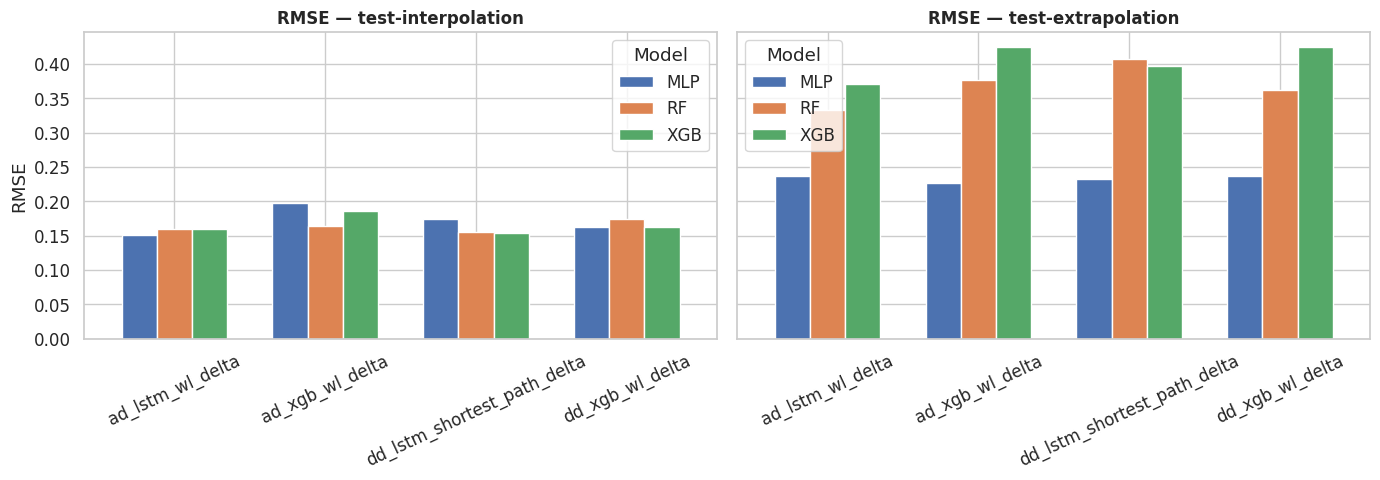

In [15]:
eval_df = results_df[results_df["split"].isin(["test-interpolation", "test-extrapolation"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, split in zip(axes, ["test-interpolation", "test-extrapolation"]):
    split_data = eval_df[eval_df["split"] == split]
    pivot = split_data.pivot(index="family", columns="model", values="RMSE")
    pivot.plot(kind="bar", ax=ax, rot=25, width=0.7)
    ax.set_title(f"RMSE — {split}", fontsize=12, fontweight="bold")
    ax.set_ylabel("RMSE")
    ax.set_xlabel("")
    ax.legend(title="Model")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bar_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

####  Feature Importance (RF & XGBoost, best family)

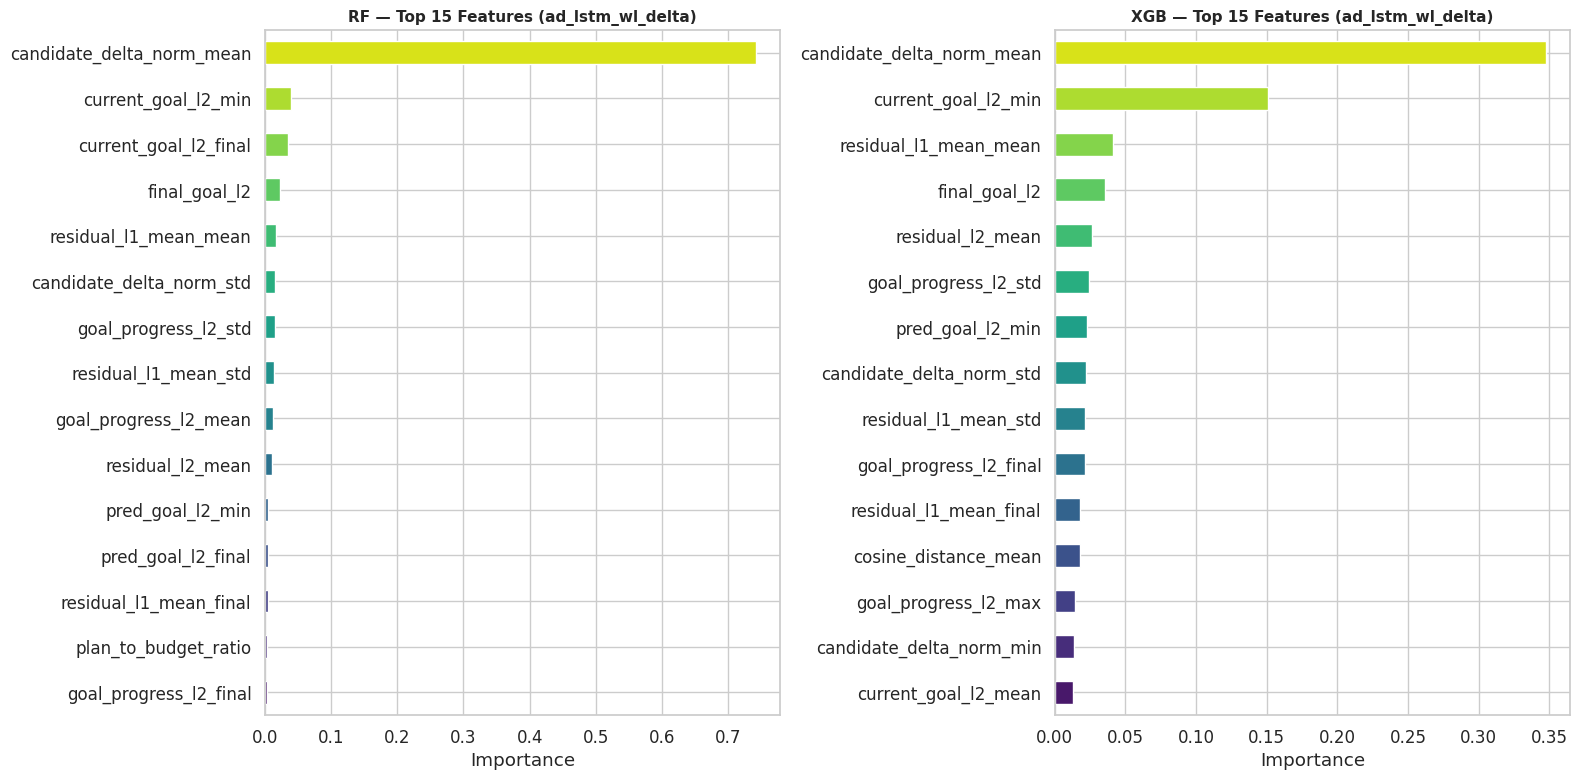

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, model_name in zip(axes, ["RF", "XGB"]):
    # Pick the family with highest R² on test-extrapolation
    best_family = results_df[
        (results_df["split"] == "test-extrapolation") & 
        (results_df["model"] == model_name)
    ].sort_values("R2", ascending=False).iloc[0]["family"]

    key = f"{model_name}_feature_importances"
    imp = all_best_params[best_family][key]
    imp_series = pd.Series(imp).sort_values(ascending=True)
    top_k = imp_series.tail(15)

    top_k.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(top_k)))
    ax.set_title(f"{model_name} — Top 15 Features ({best_family})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

#### Residual Distribution (Test-Extrapolation)

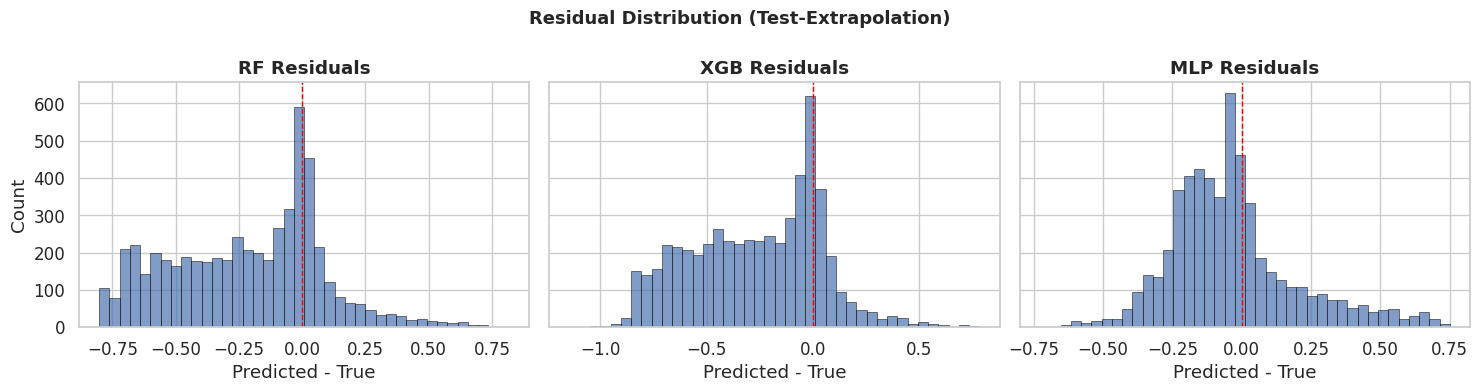

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, model_name in zip(axes, ["RF", "XGB", "MLP"]):
    residuals = []
    for family in FAMILIES:
        pred_df = pd.read_csv(RESULTS_DIR / family / "predictions.csv")
        m = pred_df[(pred_df["split"] == "test-extrapolation") & (pred_df["model"] == model_name)]
        residuals.extend((m["pred"] - m["true"]).tolist())
    
    ax.hist(residuals, bins=40, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_title(f"{model_name} Residuals", fontweight="bold")
    ax.set_xlabel("Predicted - True")
    if ax == axes[0]:
        ax.set_ylabel("Count")

plt.suptitle("Residual Distribution (Test-Extrapolation)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residual_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
**Pipeline complete.** Results saved to `results/model_comparison/seed_{SEED}`.